In [22]:
# ============================================================
# CS301 - Milestone 2: Crime vs Housing Prices in NYC
# Team: Maksym Soroka, Anthony Chahla
# ============================================================

# --- CELL 1: Install & Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")
print("All libraries loaded ✅")

All libraries loaded ✅


In [23]:
# --- CELL 2: Upload and Load Data ---
from google.colab import files
import io

print("Upload processed_nypd.csv first...")
uploaded1 = files.upload()
crime_df = pd.read_csv(io.BytesIO(list(uploaded1.values())[0]))

print("Now upload nyc_housing_base.csv...")
uploaded2 = files.upload()
housing_df = pd.read_csv(io.BytesIO(list(uploaded2.values())[0]))

print("Crime dataset shape:", crime_df.shape)
print("Housing dataset shape:", housing_df.shape)
print("\n--- Crime columns ---")
print(crime_df.columns.tolist())
print("\n--- Housing columns ---")
print(housing_df.columns.tolist())

Upload processed_nypd.csv first...


Saving processed_nypd.csv to processed_nypd (1).csv
Now upload nyc_housing_base.csv...


Saving nyc_housing_base.csv to nyc_housing_base (2).csv
Crime dataset shape: (128778, 13)
Housing dataset shape: (34439, 19)

--- Crime columns ---
['ARREST_DATE', 'PD_DESC', 'OFNS_DESC', 'LAW_CODE', 'LAW_CAT_CD', 'ARREST_BORO', 'ARREST_PRECINCT', 'JURISDICTION_CODE', 'AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'Latitude', 'Longitude']

--- Housing columns ---
['borough_x', 'block', 'lot', 'sale_price', 'zip_code', 'borough_y', 'yearbuilt', 'lotarea', 'bldgarea', 'resarea', 'comarea', 'unitsres', 'unitstotal', 'numfloors', 'latitude', 'longitude', 'landuse', 'bldgclass', 'building_age']


In [24]:
# --- CELL 3: Preview the Data ---
print(crime_df.head())
print(housing_df.head())

  ARREST_DATE                   PD_DESC          OFNS_DESC    LAW_CODE  \
0  01/03/2024                    RAPE 3               RAPE  PL 1302503   
1  01/03/2024         STRANGULATION 1ST     FELONY ASSAULT  PL 1211200   
2  01/04/2024  ASSAULT 2,1,UNCLASSIFIED     FELONY ASSAULT  PL 1201001   
3  01/15/2024      TRESPASS 3, CRIMINAL  CRIMINAL TRESPASS  PL 140100A   
4  01/07/2024  BURGLARY,RESIDENCE,NIGHT           BURGLARY  PL 1403002   

  LAW_CAT_CD ARREST_BORO  ARREST_PRECINCT  JURISDICTION_CODE AGE_GROUP  \
0          F           K               77                  0     45-64   
1          F           Q              101                  0     25-44   
2          F           K               83                  0     45-64   
3          M           S              121                  0     18-24   
4          F           Q              107                  0     45-64   

  PERP_SEX PERP_RACE   Latitude  Longitude  
0        M     BLACK  40.674496 -73.930571  
1        M     BLACK

In [25]:
# --- CELL 4: Clean and Merge Data by Borough ---

# Map crime borough codes to names
borough_map_crime = {'K': 'Brooklyn', 'Q': 'Queens', 'M': 'Manhattan',
                     'S': 'Staten Island', 'B': 'Bronx'}
crime_df['borough_name'] = crime_df['ARREST_BORO'].map(borough_map_crime)

# Count crimes per borough
crime_counts = crime_df.groupby('borough_name').size().reset_index(name='crime_count')

# Map housing borough codes to names
borough_map_housing = {1: 'Manhattan', 2: 'Bronx', 3: 'Brooklyn',
                       4: 'Queens', 5: 'Staten Island'}
housing_df['borough_name'] = housing_df['borough_x'].map(borough_map_housing)

# Clean sale_price - remove zeros and nulls
housing_df = housing_df[housing_df['sale_price'] > 10000]

# Average house price per borough
avg_price = housing_df.groupby('borough_name')['sale_price'].median().reset_index()
avg_price.columns = ['borough_name', 'median_sale_price']

# Merge the two datasets
merged_df = pd.merge(crime_counts, avg_price, on='borough_name')
print(merged_df)

    borough_name  crime_count  median_sale_price
0          Bronx        28602           710000.0
1       Brooklyn        35811          1065000.0
2      Manhattan        30563           895000.0
3         Queens        28167           760000.0
4  Staten Island         5635           735500.0


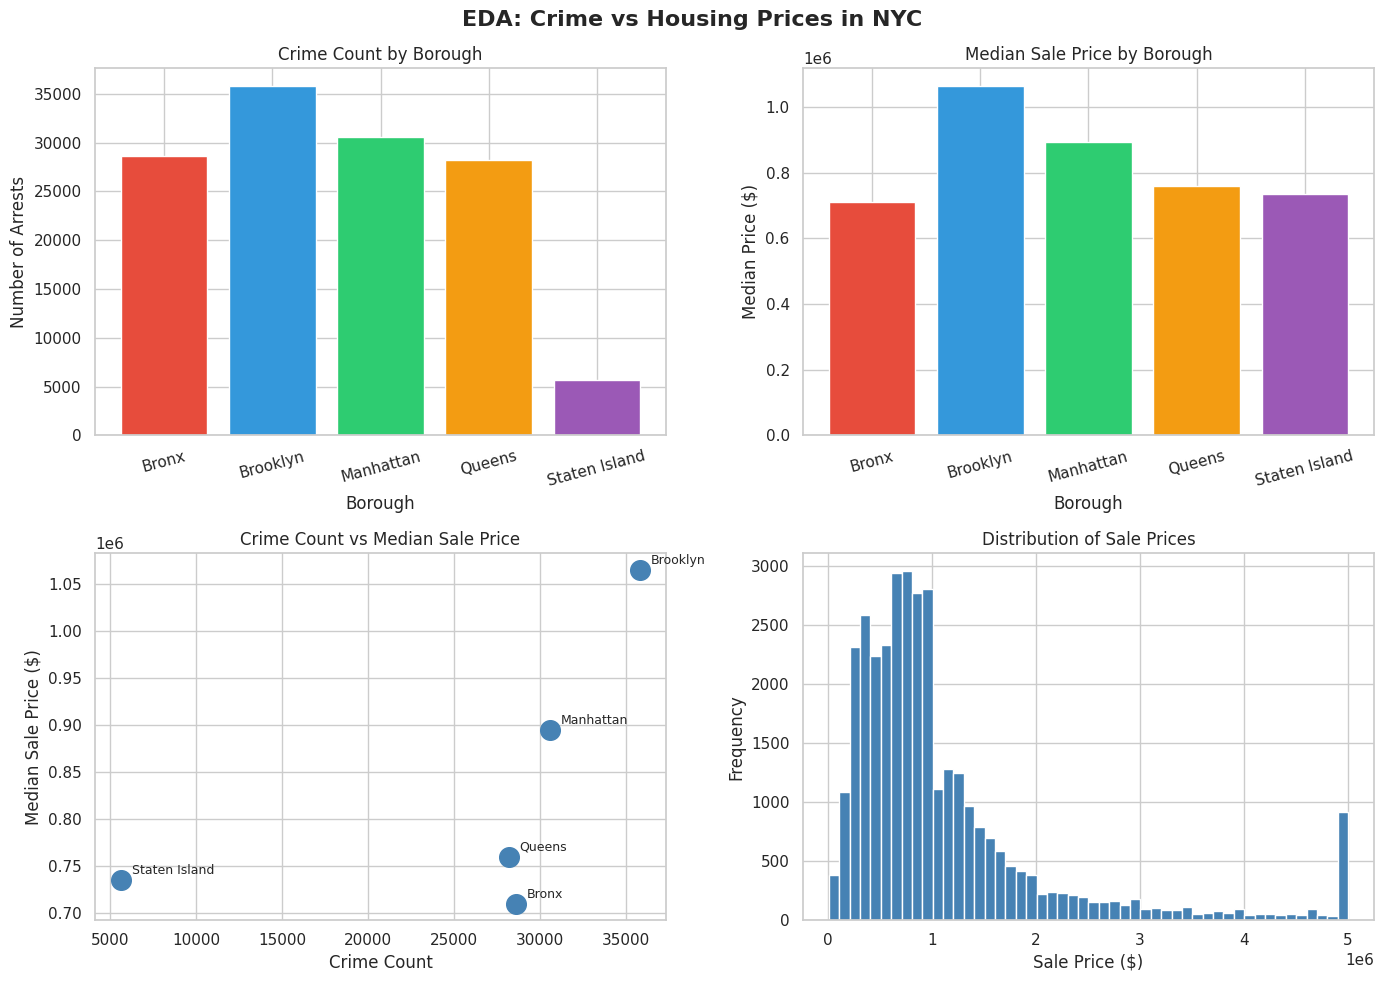

EDA plots saved! ✅


In [26]:
# --- CELL 5: EDA - Visualizations ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA: Crime vs Housing Prices in NYC', fontsize=16, fontweight='bold')

# Plot 1: Crime count by borough (bar chart)
axes[0,0].bar(merged_df['borough_name'], merged_df['crime_count'],
              color=['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6'])
axes[0,0].set_title('Crime Count by Borough')
axes[0,0].set_xlabel('Borough')
axes[0,0].set_ylabel('Number of Arrests')
axes[0,0].tick_params(axis='x', rotation=15)

# Plot 2: Median sale price by borough
axes[0,1].bar(merged_df['borough_name'], merged_df['median_sale_price'],
              color=['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6'])
axes[0,1].set_title('Median Sale Price by Borough')
axes[0,1].set_xlabel('Borough')
axes[0,1].set_ylabel('Median Price ($)')
axes[0,1].tick_params(axis='x', rotation=15)

# Plot 3: Scatter plot - crime vs price
axes[1,0].scatter(merged_df['crime_count'], merged_df['median_sale_price'],
                  color='steelblue', s=200, zorder=5)
for i, row in merged_df.iterrows():
    axes[1,0].annotate(row['borough_name'],
                       (row['crime_count'], row['median_sale_price']),
                       textcoords="offset points", xytext=(8,4), fontsize=9)
axes[1,0].set_title('Crime Count vs Median Sale Price')
axes[1,0].set_xlabel('Crime Count')
axes[1,0].set_ylabel('Median Sale Price ($)')

# Plot 4: Housing price distribution
axes[1,1].hist(housing_df['sale_price'].clip(upper=5000000),
               bins=50, color='steelblue', edgecolor='white')
axes[1,1].set_title('Distribution of Sale Prices')
axes[1,1].set_xlabel('Sale Price ($)')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved! ✅")

In [27]:
# --- CELL 6: Hypothesis Testing ---
from scipy import stats

# Split boroughs into HIGH crime and LOW crime groups
high_crime = ['Brooklyn', 'Manhattan']
low_crime = ['Staten Island', 'Queens', 'Bronx']

high_crime_prices = housing_df[housing_df['borough_name'].isin(high_crime)]['sale_price']
low_crime_prices = housing_df[housing_df['borough_name'].isin(low_crime)]['sale_price']

# Run T-Test
t_stat, p_value = stats.ttest_ind(high_crime_prices, low_crime_prices)

print("=== T-Test: High Crime vs Low Crime Borough Prices ===")
print(f"High crime boroughs median price: ${high_crime_prices.median():,.0f}")
print(f"Low crime boroughs median price:  ${low_crime_prices.median():,.0f}")
print(f"\nT-Statistic: {t_stat:.4f}")
print(f"P-Value:     {p_value:.6f}")

if p_value < 0.05:
    print("\n✅ Result: REJECT the Null Hypothesis (p < 0.05)")
    print("There IS a statistically significant difference in prices between high and low crime boroughs.")
else:
    print("\n❌ Result: FAIL TO REJECT the Null Hypothesis (p >= 0.05)")
    print("There is NO statistically significant difference in prices.")

=== T-Test: High Crime vs Low Crime Borough Prices ===
High crime boroughs median price: $995,000
Low crime boroughs median price:  $747,000

T-Statistic: 49.2273
P-Value:     0.000000

✅ Result: REJECT the Null Hypothesis (p < 0.05)
There IS a statistically significant difference in prices between high and low crime boroughs.


=== Linear Regression Results ===
R² Score: 0.0607
RMSE:     $128,308
Coefficient: 2.7646 (price change per additional crime)


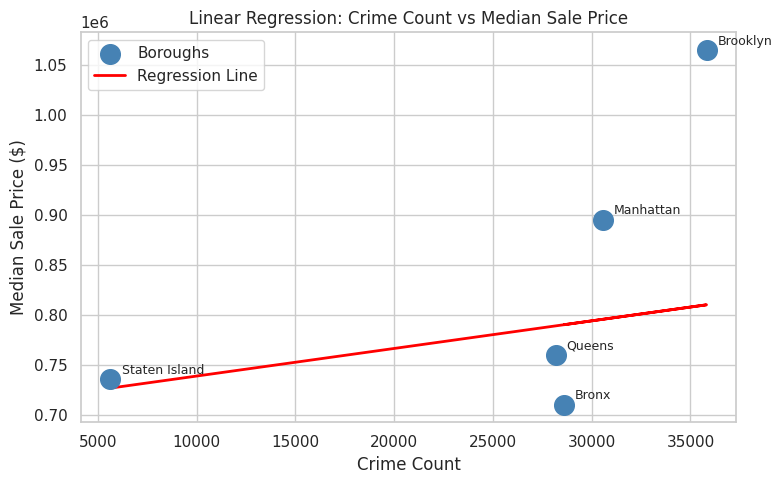

Regression plot saved! ✅


In [28]:
# --- CELL 7: Linear Regression Model ---
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Prepare data
X = merged_df[['crime_count']]
y = merged_df['median_sale_price']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X)

# Metrics
r2 = r2_score(y, y_pred)
rmse = mean_squared_error(y, y_pred) ** 0.5

print("=== Linear Regression Results ===")
print(f"R² Score: {r2:.4f}")
print(f"RMSE:     ${rmse:,.0f}")
print(f"Coefficient: {model.coef_[0]:.4f} (price change per additional crime)")

# Plot regression line
plt.figure(figsize=(8,5))
plt.scatter(merged_df['crime_count'], merged_df['median_sale_price'],
            color='steelblue', s=200, zorder=5, label='Boroughs')
for i, row in merged_df.iterrows():
    plt.annotate(row['borough_name'],
                 (row['crime_count'], row['median_sale_price']),
                 textcoords="offset points", xytext=(8,4), fontsize=9)
plt.plot(merged_df['crime_count'], y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Linear Regression: Crime Count vs Median Sale Price')
plt.xlabel('Crime Count')
plt.ylabel('Median Sale Price ($)')
plt.legend()
plt.tight_layout()
plt.savefig('regression_plot.png', dpi=150)
plt.show()
print("Regression plot saved! ✅")

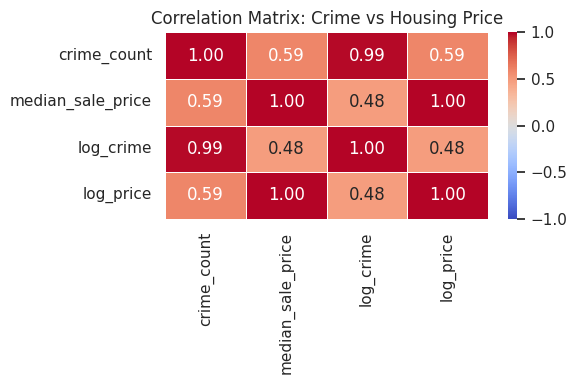

Heatmap saved! ✅


In [29]:
# --- CELL 8: Correlation Heatmap ---

# Build a numeric summary table per borough
corr_data = merged_df[['crime_count', 'median_sale_price']].copy()

# Add population density proxy (crime per borough area approximation)
corr_data['log_crime'] = np.log(corr_data['crime_count'])
corr_data['log_price'] = np.log(corr_data['median_sale_price'])

plt.figure(figsize=(6, 4))
sns.heatmap(corr_data.corr(), annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix: Crime vs Housing Price')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print("Heatmap saved! ✅")

/tmp/ipykernel_8935/4194330301.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=housing_filtered, x='borough_name', y='sale_price',
/tmp/ipykernel_8935/4194330301.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=crime_counts_type, x='borough_name', y='count',


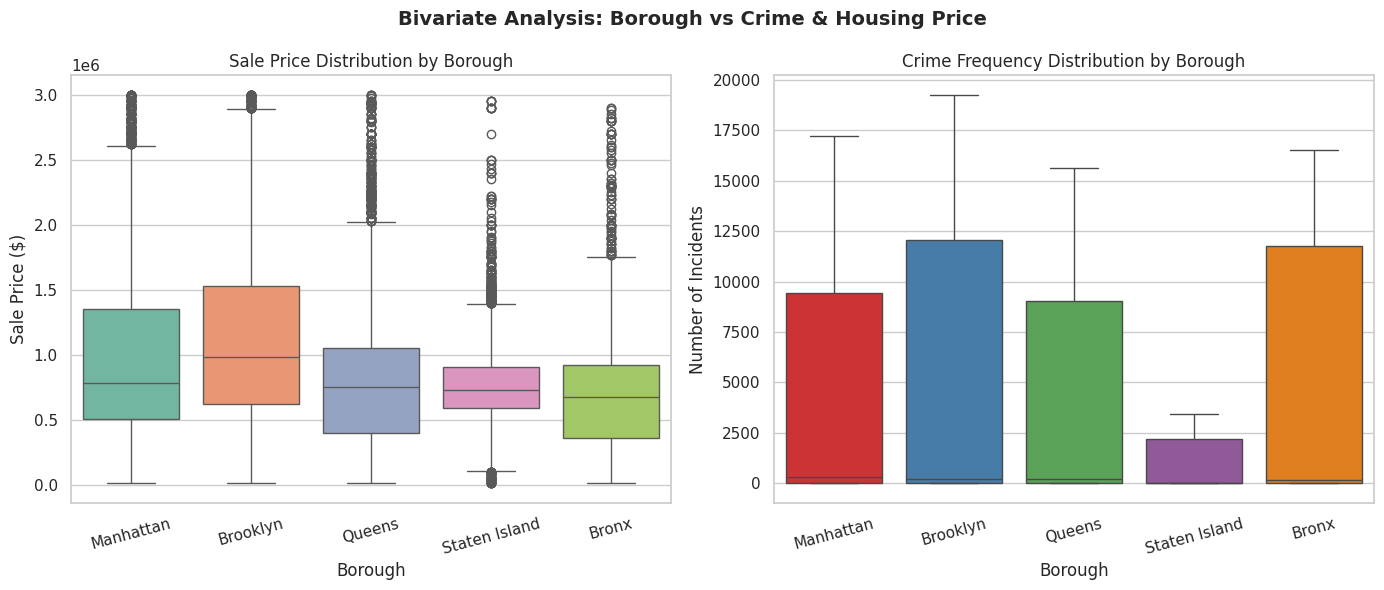

Box plots saved! ✅


In [30]:
# --- CELL 9: Bivariate Analysis - Box Plot ---

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Bivariate Analysis: Borough vs Crime & Housing Price',
             fontsize=14, fontweight='bold')

# Box Plot 1: Sale price distribution per borough
borough_order = ['Manhattan', 'Brooklyn', 'Queens', 'Staten Island', 'Bronx']

housing_filtered = housing_df[housing_df['sale_price'] < 3000000]  # remove extreme outliers
sns.boxplot(data=housing_filtered, x='borough_name', y='sale_price',
            order=borough_order, palette='Set2', ax=axes[0])
axes[0].set_title('Sale Price Distribution by Borough')
axes[0].set_xlabel('Borough')
axes[0].set_ylabel('Sale Price ($)')
axes[0].tick_params(axis='x', rotation=15)

# Box Plot 2: Crime type frequency per borough
crime_counts_type = crime_df.groupby(['borough_name', 'LAW_CAT_CD']).size().reset_index(name='count')
sns.boxplot(data=crime_counts_type, x='borough_name', y='count',
            order=borough_order, palette='Set1', ax=axes[1])
axes[1].set_title('Crime Frequency Distribution by Borough')
axes[1].set_xlabel('Borough')
axes[1].set_ylabel('Number of Incidents')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('boxplot_analysis.png', dpi=150)
plt.show()
print("Box plots saved! ✅")

## Knowledge Discovery — What We Found Out

### What We Thought Would Happen
When we started this project, we assumed that neighborhoods with more crime
would have cheaper housing prices. It seemed pretty straightforward — who
would want to pay more to live somewhere less safe?

### Finding 1: More Crime = Higher Prices? (Not What We Expected)
Brooklyn had the most arrests out of all the boroughs (35,811) but also had
the highest median sale price at $1,065,000. That was honestly surprising to
us. It made us realize that crime alone doesn't determine how expensive
an area is.

### Finding 2: Crime Doesn't Really Predict Price That Well (R² = 0.06)
Our regression model showed that crime count only explains about 6% of why
housing prices change between boroughs. That's really low. It means other
things like how close you are to the subway, what schools are nearby, or
how popular the neighborhood is probably matter way more.

### Finding 3: The Difference Is Real, Just Not in the Direction We Expected
Our T-Test gave us a p-value basically equal to 0, which means the price
difference between high and low crime boroughs is statistically significant.
But the twist is that the higher crime boroughs are actually the more
expensive ones.

### What This Means in Real Life
If the city wanted to use this data to make decisions, they probably shouldn't
rely on just crime rates to figure out where housing is affordable or not.
A neighborhood like Brooklyn shows that people are still willing to pay a lot
to live somewhere with good food, culture, and transit — even if the crime
rate is higher. A better approach would be to combine crime data with things
like income levels, school ratings, and access to public transportation.